In [1]:
# ══════════════════════════════════════════════════════════
# CELDA 1 — Librerías y carga de datos 2019-2025
# ══════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

BASE    = '/content/drive/MyDrive/TFM_Seguridad_Vial'
outputs = f'{BASE}/outputs'
raw     = f'{BASE}/datos/accidentes_general/raw'

TOP3 = ['CENTRO', 'CHAMBERÍ', 'SALAMANCA']

mapa_gravedad = {
    1: 'leve', 2: 'leve', 5: 'leve', 6: 'leve', 7: 'leve',
    3: 'grave', 4: 'fallecido', 14: 'sin_asistencia', 77: 'desconocido'
}

# Cargamos todos los ficheros 2019-2025
dfs = []
for año in range(2019, 2026):
    try:
        df = pd.read_csv(f'{raw}/Accidentes{año}.csv',
                         sep=';', encoding='utf-8-sig')
        df.columns = (df.columns.str.strip()
                                .str.lower()
                                .str.replace('ó', 'o', regex=False)
                                .str.replace('é', 'e', regex=False)
                                .str.replace('í', 'i', regex=False)
                                .str.replace(' ', '_', regex=False))
        df['año'] = año
        dfs.append(df)
        print(f'✅ {año}: {len(df):,} registros')
    except Exception as e:
        print(f'⚠️ {año}: {e}')

df_raw = pd.concat(dfs, ignore_index=True)

# Limpieza general
df_raw['distrito'] = (df_raw['distrito']
                      .str.strip()
                      .str.upper()
                      .str.replace(' - ', '-', regex=False))
df_raw['hora_dt']  = pd.to_datetime(df_raw['hora'], format='%H:%M:%S', errors='coerce')
df_raw['hora_int'] = df_raw['hora_dt'].dt.hour
df_raw['fecha_dt'] = pd.to_datetime(df_raw['fecha'], dayfirst=True, errors='coerce')
df_raw['mes']      = df_raw['fecha_dt'].dt.month
df_raw['dia_sem']  = df_raw['fecha_dt'].dt.day_name()
df_raw['gravedad'] = df_raw['cod_lesividad'].map(mapa_gravedad).fillna('sin_asistencia')

# Normalización de acentos para filtro VRU
def quitar_acentos(s):
    return (s.str.replace('á', 'a', regex=False)
             .str.replace('é', 'e', regex=False)
             .str.replace('í', 'i', regex=False)
             .str.replace('ó', 'o', regex=False)
             .str.replace('ú', 'u', regex=False)
             .str.replace('Á', 'A', regex=False)
             .str.replace('É', 'E', regex=False)
             .str.replace('Í', 'I', regex=False)
             .str.replace('Ó', 'O', regex=False)
             .str.replace('Ú', 'U', regex=False))

tipo_persona_norm  = quitar_acentos(df_raw['tipo_persona'].str.strip().str.lower())
tipo_vehiculo_norm = quitar_acentos(df_raw['tipo_vehiculo'].str.strip().str.lower())

# Filtramos VRU: peatones y ciclistas
vru_mask = (
    (tipo_persona_norm == 'peaton') |
    (tipo_vehiculo_norm.str.contains('bici', na=False))
)
df_vru = df_raw[vru_mask].copy()
df_vru['tipo_vru'] = np.where(
    tipo_vehiculo_norm[vru_mask].str.contains('bici', na=False),
    'Ciclista', 'Peatón'
)

# Verificación del filtro
print(f'\n=== VERIFICACIÓN FILTRO VRU ===')
print(f'tipo_vru únicos: {df_vru["tipo_vru"].value_counts().to_dict()}')

# Filtramos Top 3
df_top3 = df_vru[df_vru['distrito'].isin(TOP3)].copy()

print(f'\n✅ Datos cargados: {df_raw.shape[0]:,} registros totales (2019-2025)')
print(f'✅ VRU total: {df_vru.shape[0]:,} registros')
print(f'  Peatones: {(df_vru["tipo_vru"]=="Peatón").sum():,}')
print(f'  Ciclistas: {(df_vru["tipo_vru"]=="Ciclista").sum():,}')
print(f'✅ Top 3 distritos: {df_top3.shape[0]:,} registros VRU')
print(f'\nRegistros por distrito y tipo:')
print(df_top3.groupby(['distrito','tipo_vru'])['num_expediente']
      .count().unstack(fill_value=0).to_string())

Mounted at /content/drive
✅ 2019: 51,811 registros
✅ 2020: 32,433 registros
✅ 2021: 41,783 registros
✅ 2022: 47,053 registros
✅ 2023: 48,830 registros
✅ 2024: 49,340 registros
✅ 2025: 51,067 registros

=== VERIFICACIÓN FILTRO VRU ===
tipo_vru únicos: {'Peatón': 10558, 'Ciclista': 6841}

✅ Datos cargados: 322,317 registros totales (2019-2025)
✅ VRU total: 17,399 registros
  Peatones: 10,558
  Ciclistas: 6,841
✅ Top 3 distritos: 3,819 registros VRU

Registros por distrito y tipo:
tipo_vru   Ciclista  Peatón
distrito                   
CENTRO          874     888
CHAMBERÍ        418     526
SALAMANCA       481     632


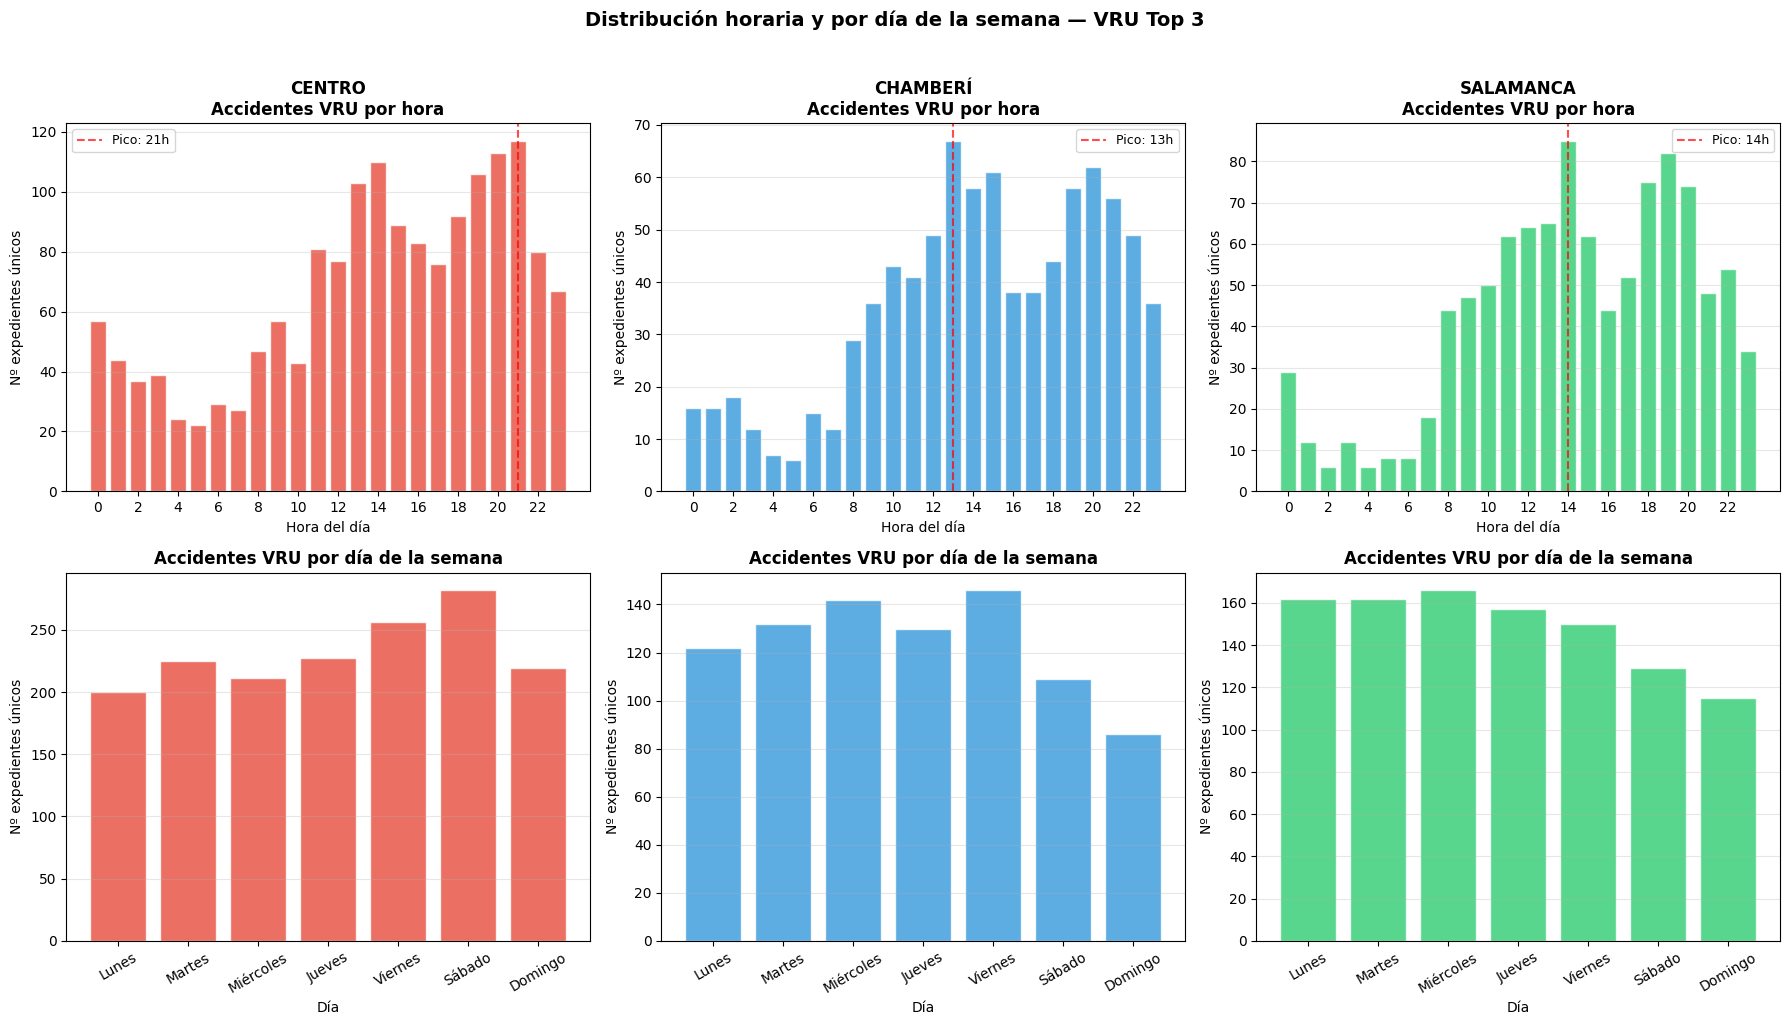


=== HORAS PICO POR DISTRITO ===

CENTRO:
  Top 3 horas: [21, 20, 14] h
  Hora más peligrosa: 21h (117 accidentes)
  Por franja: {'Nocturna (0-6h)': 15.6, 'Mañana punta (7-9h)': 8.1, 'Mediodía (10-14h)': 25.6, 'Tarde (15-20h)': 34.5, 'Noche (21-23h)': 16.3}

CHAMBERÍ:
  Top 3 horas: [13, 20, 15] h
  Hora más peligrosa: 13h (67 accidentes)
  Por franja: {'Nocturna (0-6h)': 10.4, 'Mañana punta (7-9h)': 8.9, 'Mediodía (10-14h)': 29.8, 'Tarde (15-20h)': 34.7, 'Noche (21-23h)': 16.3}

SALAMANCA:
  Top 3 horas: [14, 19, 18] h
  Hora más peligrosa: 14h (85 accidentes)
  Por franja: {'Nocturna (0-6h)': 7.8, 'Mañana punta (7-9h)': 10.5, 'Mediodía (10-14h)': 31.3, 'Tarde (15-20h)': 37.4, 'Noche (21-23h)': 13.1}
✅ top3_horario_diasemana.png guardada


In [2]:
# ══════════════════════════════════════════════════════════
# CELDA 2 — Análisis horario y por día de la semana
# ══════════════════════════════════════════════════════════

orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dias_es    = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribución horaria y por día de la semana — VRU Top 3',
             fontsize=14, fontweight='bold', y=1.02)

colores = {'CENTRO': '#E74C3C', 'CHAMBERÍ': '#3498DB', 'SALAMANCA': '#2ECC71'}

for col, distrito in enumerate(TOP3):
    d = df_top3[df_top3['distrito'] == distrito]

    # Fila 1: distribución por hora
    ax = axes[0][col]
    hora_counts = d.groupby('hora_int')['num_expediente'].nunique()
    hora_counts = hora_counts.reindex(range(24), fill_value=0)
    ax.bar(hora_counts.index, hora_counts.values,
           color=colores[distrito], alpha=0.8, edgecolor='white')
    ax.set_title(f'{distrito}\nAccidentes VRU por hora', fontweight='bold')
    ax.set_xlabel('Hora del día')
    ax.set_ylabel('Nº expedientes únicos')
    ax.set_xticks(range(0, 24, 2))

    # Marcamos hora pico
    hora_pico = hora_counts.idxmax()
    ax.axvline(x=hora_pico, color='red', linestyle='--', alpha=0.7,
               label=f'Pico: {hora_pico}h')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # Fila 2: distribución por día de la semana
    ax2 = axes[1][col]
    dia_counts = d.groupby('dia_sem')['num_expediente'].nunique()
    dia_counts = dia_counts.reindex(orden_dias, fill_value=0)
    dia_counts.index = dias_es
    ax2.bar(dia_counts.index, dia_counts.values,
            color=colores[distrito], alpha=0.8, edgecolor='white')
    ax2.set_title(f'Accidentes VRU por día de la semana', fontweight='bold')
    ax2.set_xlabel('Día')
    ax2.set_ylabel('Nº expedientes únicos')
    ax2.tick_params(axis='x', rotation=30)
    ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{outputs}/top3_horario_diasemana.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen horas pico
print('\n=== HORAS PICO POR DISTRITO ===')
for distrito in TOP3:
    d = df_top3[df_top3['distrito'] == distrito]
    hora_counts = d.groupby('hora_int')['num_expediente'].nunique().sort_values(ascending=False)
    print(f'\n{distrito}:')
    print(f'  Top 3 horas: {hora_counts.head(3).index.tolist()} h')
    print(f'  Hora más peligrosa: {hora_counts.index[0]}h ({hora_counts.iloc[0]} accidentes)')

    # Franjas horarias
    d = d.copy()
    d['franja'] = pd.cut(d['hora_int'],
        bins=[-1, 6, 9, 14, 20, 23],
        labels=['Nocturna (0-6h)', 'Mañana punta (7-9h)',
                'Mediodía (10-14h)', 'Tarde (15-20h)', 'Noche (21-23h)'])
    franja = d.groupby('franja', observed=True)['num_expediente'].nunique()
    franja_pct = (franja / franja.sum() * 100).round(1)
    print(f'  Por franja: {franja_pct.to_dict()}')
print('✅ top3_horario_diasemana.png guardada')

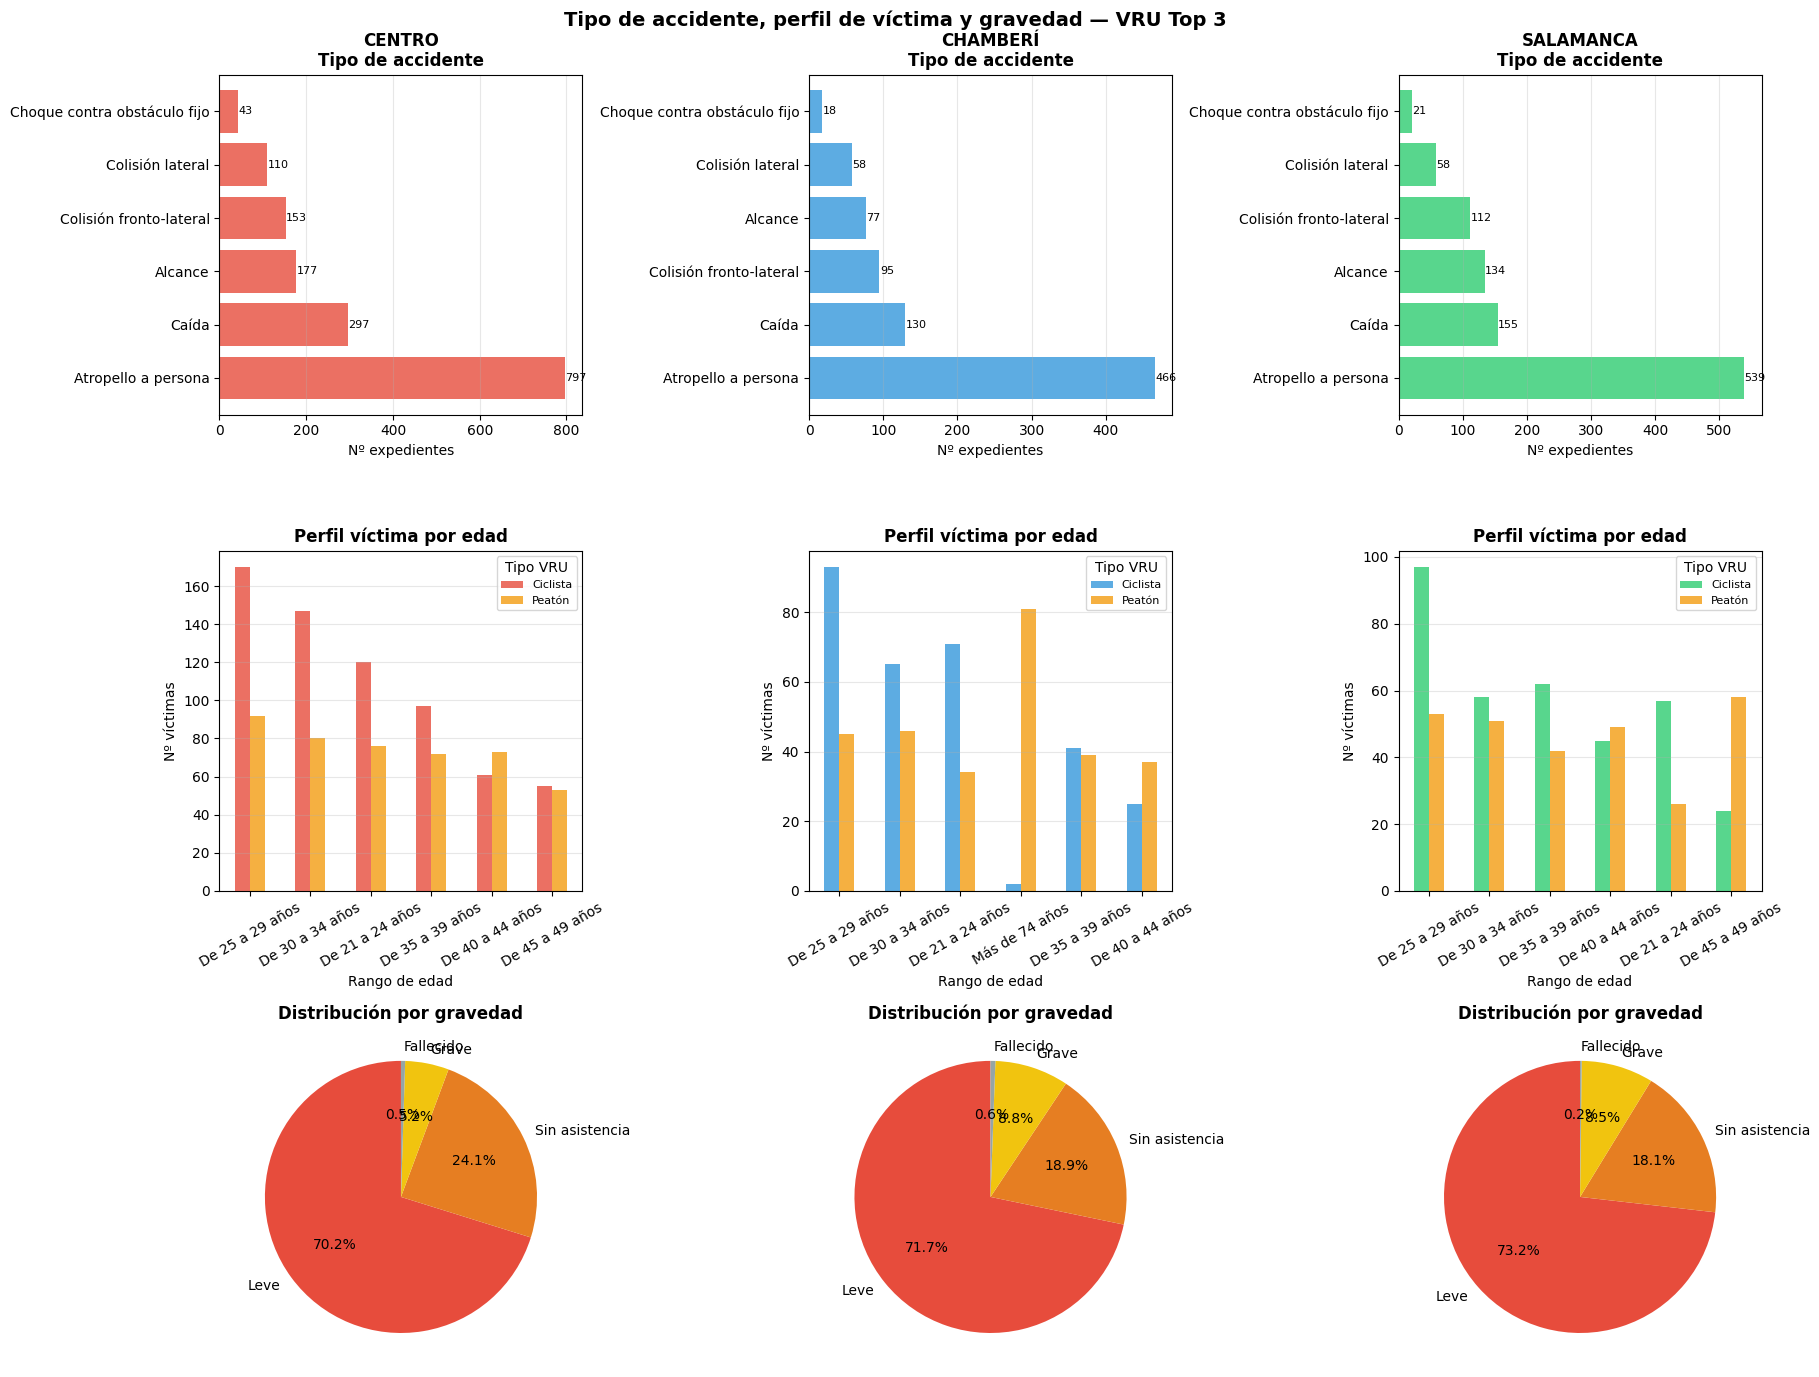


=== GRAVEDAD POR DISTRITO ===

CENTRO: 1620 accidentes VRU únicos (2019-2025)
  Graves+Fallecidos: 92 (5.7%)
  {'Leve': 1137, 'Sin asistencia': 391, 'Grave': 84, 'Fallecido': 8}

CHAMBERÍ: 867 accidentes VRU únicos (2019-2025)
  Graves+Fallecidos: 81 (9.3%)
  {'Leve': 622, 'Sin asistencia': 164, 'Grave': 76, 'Fallecido': 5}

SALAMANCA: 1041 accidentes VRU únicos (2019-2025)
  Graves+Fallecidos: 91 (8.7%)
  {'Leve': 762, 'Sin asistencia': 188, 'Grave': 89, 'Fallecido': 2}
✅ top3_tipo_perfil_gravedad.png guardada


In [3]:
# ══════════════════════════════════════════════════════════
# CELDA 3 — Tipo de accidente, perfil víctima y gravedad
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Tipo de accidente, perfil de víctima y gravedad — VRU Top 3',
             fontsize=14, fontweight='bold')

for col, distrito in enumerate(TOP3):
    d = df_top3[df_top3['distrito'] == distrito].copy()

    # Deduplicamos por expediente para análisis de accidente
    exp = d.groupby('num_expediente').agg(
        tipo_accidente=('tipo_accidente', 'first'),
        gravedad_max  =('gravedad', lambda x:
            x.map({'fallecido':4,'grave':3,'leve':2,
                   'sin_asistencia':1,'desconocido':0}).max()),
        tipo_vru      =('tipo_vru', lambda x:
            'Mixto' if x.nunique() > 1 else x.iloc[0]),
        año           =('año', 'first')
    ).reset_index()
    exp['gravedad_label'] = exp['gravedad_max'].map(
        {4:'Fallecido', 3:'Grave', 2:'Leve', 1:'Sin asistencia', 0:'Desconocido'})

    # Fila 1: tipo de accidente
    ax = axes[0][col]
    tipo_counts = exp['tipo_accidente'].value_counts().head(6)
    ax.barh(tipo_counts.index, tipo_counts.values,
            color=colores[distrito], alpha=0.8)
    ax.set_title(f'{distrito}\nTipo de accidente', fontweight='bold')
    ax.set_xlabel('Nº expedientes')
    ax.grid(axis='x', alpha=0.3)
    for i, v in enumerate(tipo_counts.values):
        ax.text(v + 0.5, i, str(v), va='center', fontsize=8)

    # Fila 2: perfil víctima (peatón vs ciclista + edad)
    ax2 = axes[1][col]
    perfil = d.groupby(['tipo_vru', 'rango_edad'])['num_expediente'].count() \
              .unstack(fill_value=0)
    # Top 6 rangos de edad
    top_edades = d['rango_edad'].value_counts().head(6).index
    perfil = perfil.reindex(columns=top_edades, fill_value=0)
    perfil.T.plot(kind='bar', ax=ax2,
                  color=[colores[distrito], '#F39C12'], alpha=0.8)
    ax2.set_title(f'Perfil víctima por edad', fontweight='bold')
    ax2.set_xlabel('Rango de edad')
    ax2.set_ylabel('Nº víctimas')
    ax2.tick_params(axis='x', rotation=30)
    ax2.legend(title='Tipo VRU', fontsize=8)
    ax2.grid(axis='y', alpha=0.3)

    # Fila 3: gravedad
    ax3 = axes[2][col]
    grav_counts = exp['gravedad_label'].value_counts()
    colores_grav = ['#E74C3C', '#E67E22', '#F1C40F', '#95A5A6', '#BDC3C7']
    wedges, texts, autotexts = ax3.pie(
        grav_counts.values,
        labels=grav_counts.index,
        autopct='%1.1f%%',
        colors=colores_grav[:len(grav_counts)],
        startangle=90
    )
    ax3.set_title(f'Distribución por gravedad', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{outputs}/top3_tipo_perfil_gravedad.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen gravedad
print('\n=== GRAVEDAD POR DISTRITO ===')
for distrito in TOP3:
    d = df_top3[df_top3['distrito'] == distrito]
    exp = d.groupby('num_expediente').agg(
        gravedad_max=('gravedad', lambda x:
            x.map({'fallecido':4,'grave':3,'leve':2,
                   'sin_asistencia':1,'desconocido':0}).max())
    ).reset_index()
    exp['gravedad_label'] = exp['gravedad_max'].map(
        {4:'Fallecido',3:'Grave',2:'Leve',1:'Sin asistencia',0:'Desconocido'})
    total = len(exp)
    graves = (exp['gravedad_label'].isin(['Fallecido','Grave'])).sum()
    print(f'\n{distrito}: {total} accidentes VRU únicos (2019-2025)')
    print(f'  Graves+Fallecidos: {graves} ({graves/total*100:.1f}%)')
    print(f'  {exp["gravedad_label"].value_counts().to_dict()}')
print('✅ top3_tipo_perfil_gravedad.png guardada')

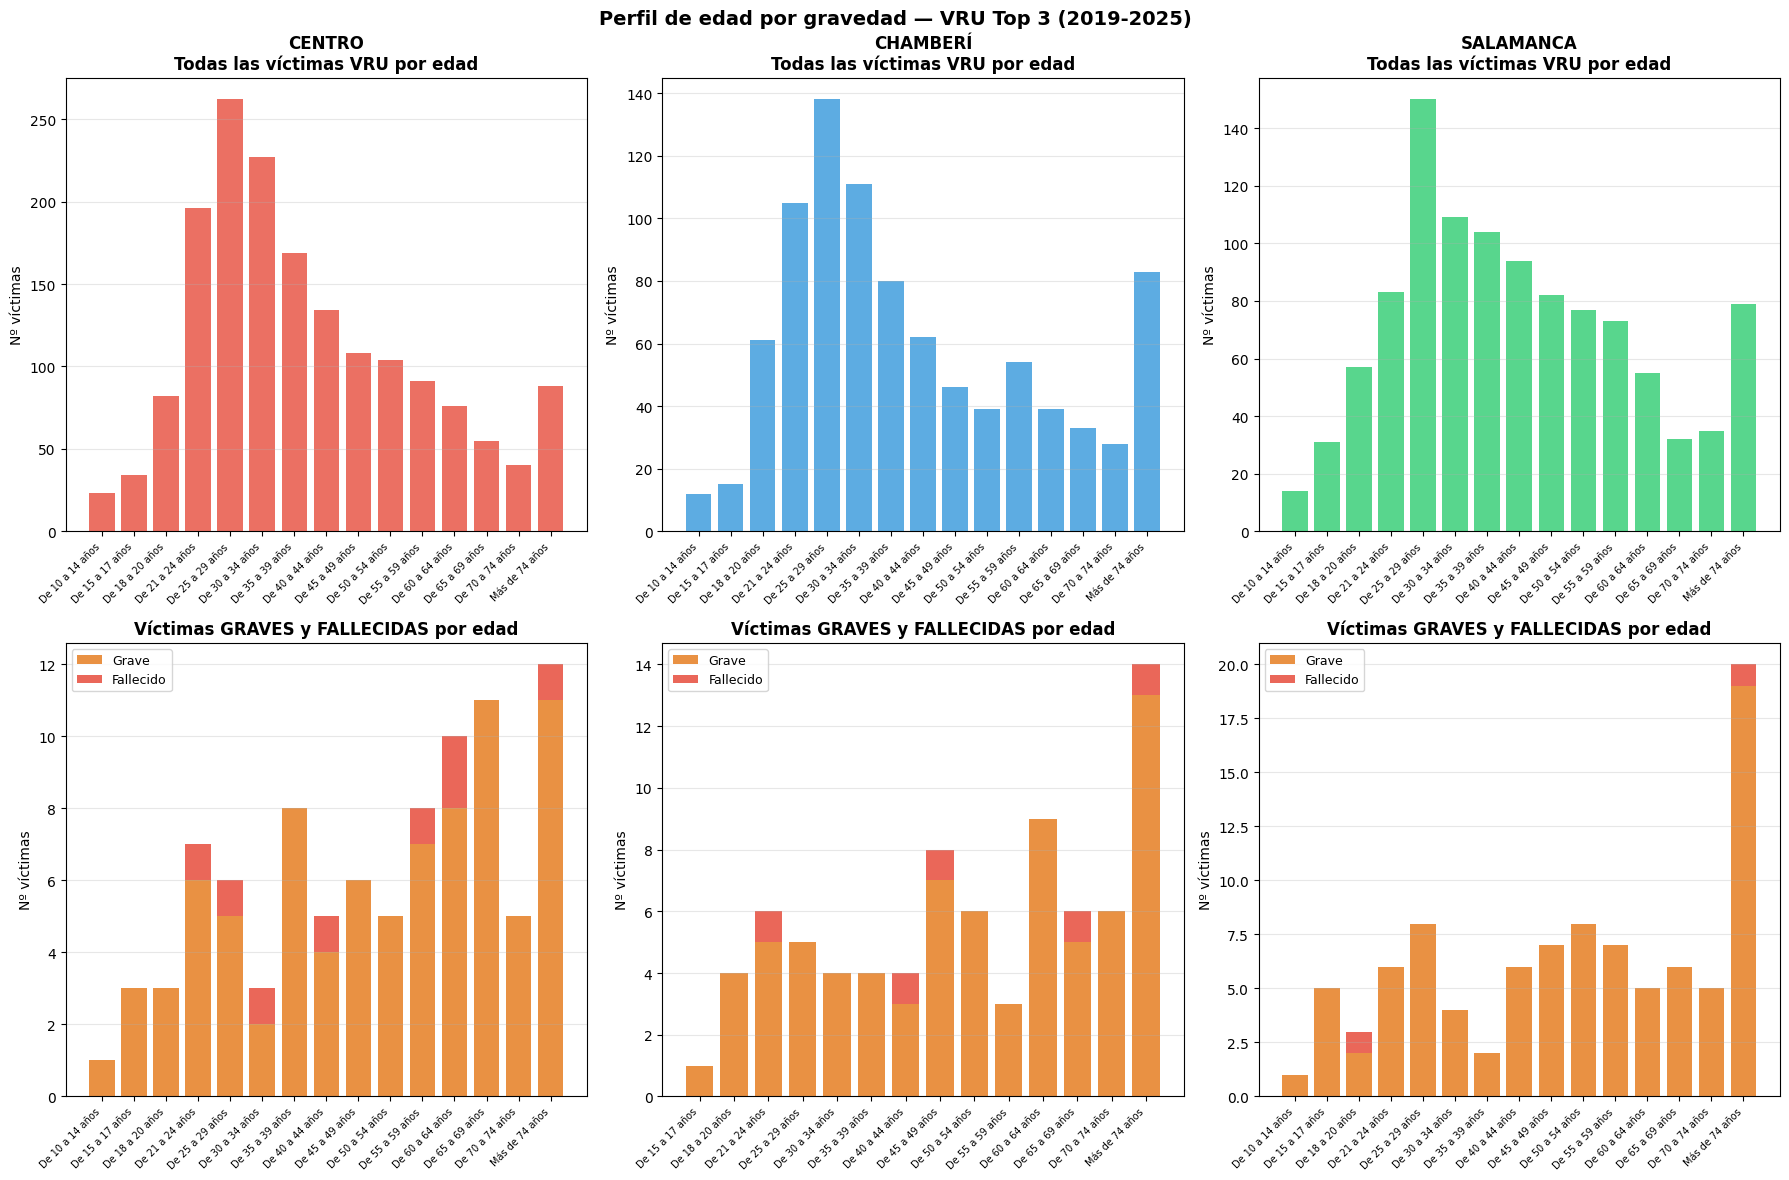

=== FALLECIDOS POR EDAD Y DISTRITO ===

CENTRO — 8 fallecidos:
     rango_edad tipo_vru  fallecidos
De 60 a 64 años   Peatón           2
De 25 a 29 años   Peatón           1
De 21 a 24 años   Peatón           1
De 30 a 34 años   Peatón           1
De 40 a 44 años   Peatón           1
De 55 a 59 años   Peatón           1
 Más de 74 años   Peatón           1

CHAMBERÍ — 5 fallecidos:
     rango_edad tipo_vru  fallecidos
De 21 a 24 años   Peatón           1
De 40 a 44 años   Peatón           1
De 45 a 49 años   Peatón           1
De 65 a 69 años   Peatón           1
 Más de 74 años   Peatón           1

SALAMANCA — 2 fallecidos:
     rango_edad tipo_vru  fallecidos
De 18 a 20 años   Peatón           1
 Más de 74 años   Peatón           1

=== GRAVES + FALLECIDOS POR RANGO DE EDAD (TOP 3 DISTRITOS COMBINADO) ===

     rango_edad  grave  fallecido  total_graves_fall
 Más de 74 años     43          3                 46
De 60 a 64 años     22          2                 24
De 65 a 69 años     

In [4]:
# ══════════════════════════════════════════════════════════
# CELDA 3B — Análisis por edad: víctimas graves y fallecidos
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Perfil de edad por gravedad — VRU Top 3 (2019-2025)',
             fontsize=14, fontweight='bold')

orden_edad = [
    'Menos de 5 años', 'De 5 a 9 años', 'De 10 a 14 años',
    'De 15 a 17 años', 'De 18 a 20 años', 'De 21 a 24 años',
    'De 25 a 29 años', 'De 30 a 34 años', 'De 35 a 39 años',
    'De 40 a 44 años', 'De 45 a 49 años', 'De 50 a 54 años',
    'De 55 a 59 años', 'De 60 a 64 años', 'De 65 a 69 años',
    'De 70 a 74 años', 'Más de 74 años'
]

for col, distrito in enumerate(TOP3):
    d = df_top3[df_top3['distrito'] == distrito].copy()

    # Fila 1 — Distribución por edad de TODOS los VRU
    ax = axes[0][col]
    edad_total = d.groupby('rango_edad')['num_expediente'].count()
    edad_total = edad_total.reindex(
        [e for e in orden_edad if e in edad_total.index]
    )
    ax.bar(range(len(edad_total)), edad_total.values,
           color=colores[distrito], alpha=0.8)
    ax.set_xticks(range(len(edad_total)))
    ax.set_xticklabels(edad_total.index, rotation=45, ha='right', fontsize=7)
    ax.set_title(f'{distrito}\nTodas las víctimas VRU por edad',
                 fontweight='bold')
    ax.set_ylabel('Nº víctimas')
    ax.grid(axis='y', alpha=0.3)

    # Fila 2 — Distribución por edad de GRAVES Y FALLECIDOS
    ax2 = axes[1][col]
    d_graves = d[d['gravedad'].isin(['grave', 'fallecido'])]
    edad_graves = d_graves.groupby(['rango_edad', 'gravedad'])['num_expediente'].count().unstack(fill_value=0)

    # Aseguramos que existen ambas columnas
    if 'grave' not in edad_graves.columns:
        edad_graves['grave'] = 0
    if 'fallecido' not in edad_graves.columns:
        edad_graves['fallecido'] = 0

    edad_graves = edad_graves.reindex(
        [e for e in orden_edad if e in edad_graves.index]
    )

    x = range(len(edad_graves))
    ax2.bar(x, edad_graves['grave'].values,
            label='Grave', color='#E67E22', alpha=0.85)
    ax2.bar(x, edad_graves['fallecido'].values,
            bottom=edad_graves['grave'].values,
            label='Fallecido', color='#E74C3C', alpha=0.85)
    ax2.set_xticks(x)
    ax2.set_xticklabels(edad_graves.index, rotation=45, ha='right', fontsize=7)
    ax2.set_title(f'Víctimas GRAVES y FALLECIDAS por edad',
                 fontweight='bold')
    ax2.set_ylabel('Nº víctimas')
    ax2.legend(fontsize=9)
    ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{outputs}/top3_edad_gravedad.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabla detallada de fallecidos ────────────────────────
print('=== FALLECIDOS POR EDAD Y DISTRITO ===\n')
for distrito in TOP3:
    d = df_top3[df_top3['distrito'] == distrito]
    fallecidos = d[d['gravedad'] == 'fallecido']
    print(f'{distrito} — {len(fallecidos)} fallecidos:')
    if len(fallecidos) > 0:
        print(fallecidos.groupby(['rango_edad', 'tipo_vru'])['num_expediente']
              .count().reset_index()
              .rename(columns={'num_expediente': 'fallecidos'})
              .sort_values('fallecidos', ascending=False)
              .to_string(index=False))
    print()

# ── Tabla graves+fallecidos por edad ─────────────────────
print('=== GRAVES + FALLECIDOS POR RANGO DE EDAD (TOP 3 DISTRITOS COMBINADO) ===\n')
graves_todos = df_top3[df_top3['gravedad'].isin(['grave','fallecido'])]
tabla_edad = (
    graves_todos.groupby(['rango_edad', 'gravedad'])['num_expediente']
    .count().unstack(fill_value=0)
    .reset_index()
)
if 'fallecido' not in tabla_edad.columns:
    tabla_edad['fallecido'] = 0
if 'grave' not in tabla_edad.columns:
    tabla_edad['grave'] = 0
tabla_edad['total_graves_fall'] = tabla_edad['grave'] + tabla_edad['fallecido']
tabla_edad = tabla_edad.sort_values('total_graves_fall', ascending=False)
print(tabla_edad[['rango_edad','grave','fallecido','total_graves_fall']].to_string(index=False))

print('\n✅ top3_edad_gravedad.png guardada')

=== TOP 10 CALLES MÁS PELIGROSAS POR DISTRITO ===

─────────────────────────────────────────────────────────────────
CENTRO
─────────────────────────────────────────────────────────────────
Calle                                      Acc  Graves   Peat   Bici
─────────────────────────────────────────────────────────────────
CALL. GRAN VIA,                             80       9     44     44
CALL. SAN BERNARDO,                         53       1     30     27
CALL. TOLEDO,                               50       4     29     25
PASEO. PRADO,                               44       3     24     23
CALL. ATOCHA,                               36       0     16     23
CALL. MAYOR,                                30       0     18     18
CALL. HORTALEZA,                            29       0     17     16
CALL. ALCALA,                               29       1      6     29
CALL. FUENCARRAL,                           26       1     17     14
PLAZA. EMPERADOR CARLOS V,                  20       2

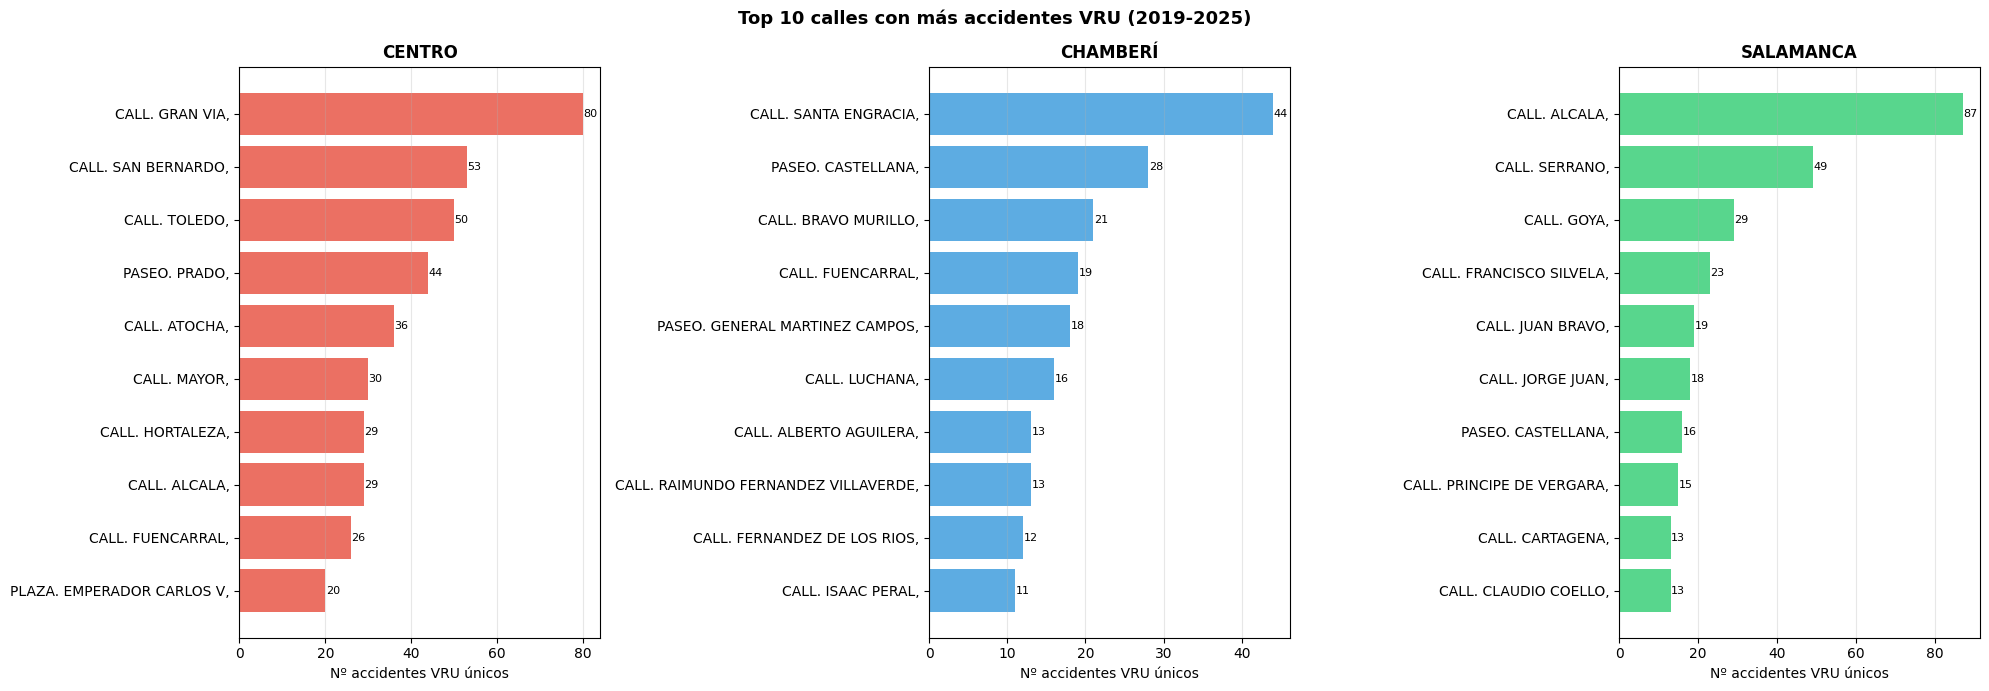

✅ top3_calles_peligrosas.png guardada


In [5]:
# ══════════════════════════════════════════════════════════
# CELDA 4 — Calles más peligrosas por distrito
# ══════════════════════════════════════════════════════════

print('=== TOP 10 CALLES MÁS PELIGROSAS POR DISTRITO ===\n')

for distrito in TOP3:
    d = df_top3[df_top3['distrito'] == distrito].copy()

    # Normalizamos nombre de calle
    d['calle'] = d['localizacion'].str.strip().str.upper() \
                                  .str.replace(r'\s+', ' ', regex=True) \
                                  .str.replace(r'\d+$', '', regex=True).str.strip()

    calles = (
        d.groupby('calle')
         .agg(
             expedientes =('num_expediente', 'nunique'),
             graves_mort =('gravedad', lambda x:
                 x.isin(['grave','fallecido']).sum()),
             peatones    =('tipo_vru', lambda x: (x == 'Peatón').sum()),
             ciclistas   =('tipo_vru', lambda x: (x == 'Ciclista').sum())
         )
         .sort_values('expedientes', ascending=False)
         .head(10)
         .reset_index()
    )

    print(f'{'─'*65}')
    print(f'{distrito}')
    print(f'{'─'*65}')
    print(f'{"Calle":<40} {"Acc":>5} {"Graves":>7} {"Peat":>6} {"Bici":>6}')
    print(f'{'─'*65}')
    for _, row in calles.iterrows():
        calle_short = row['calle'][:39]
        print(f'{calle_short:<40} {row["expedientes"]:>5} '
              f'{row["graves_mort"]:>7} {row["peatones"]:>6} {row["ciclistas"]:>6}')
    print()

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Top 10 calles con más accidentes VRU (2019-2025)',
             fontsize=13, fontweight='bold')

for col, distrito in enumerate(TOP3):
    d = df_top3[df_top3['distrito'] == distrito].copy()
    d['calle'] = d['localizacion'].str.strip().str.upper() \
                                  .str.replace(r'\s+', ' ', regex=True) \
                                  .str.replace(r'\d+$', '', regex=True).str.strip()
    calles = d.groupby('calle')['num_expediente'].nunique() \
               .sort_values(ascending=False).head(10)

    ax = axes[col]
    ax.barh(calles.index[::-1], calles.values[::-1],
            color=colores[distrito], alpha=0.8)
    ax.set_title(f'{distrito}', fontweight='bold')
    ax.set_xlabel('Nº accidentes VRU únicos')
    ax.grid(axis='x', alpha=0.3)
    for i, v in enumerate(calles.values[::-1]):
        ax.text(v + 0.1, i, str(v), va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{outputs}/top3_calles_peligrosas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ top3_calles_peligrosas.png guardada')

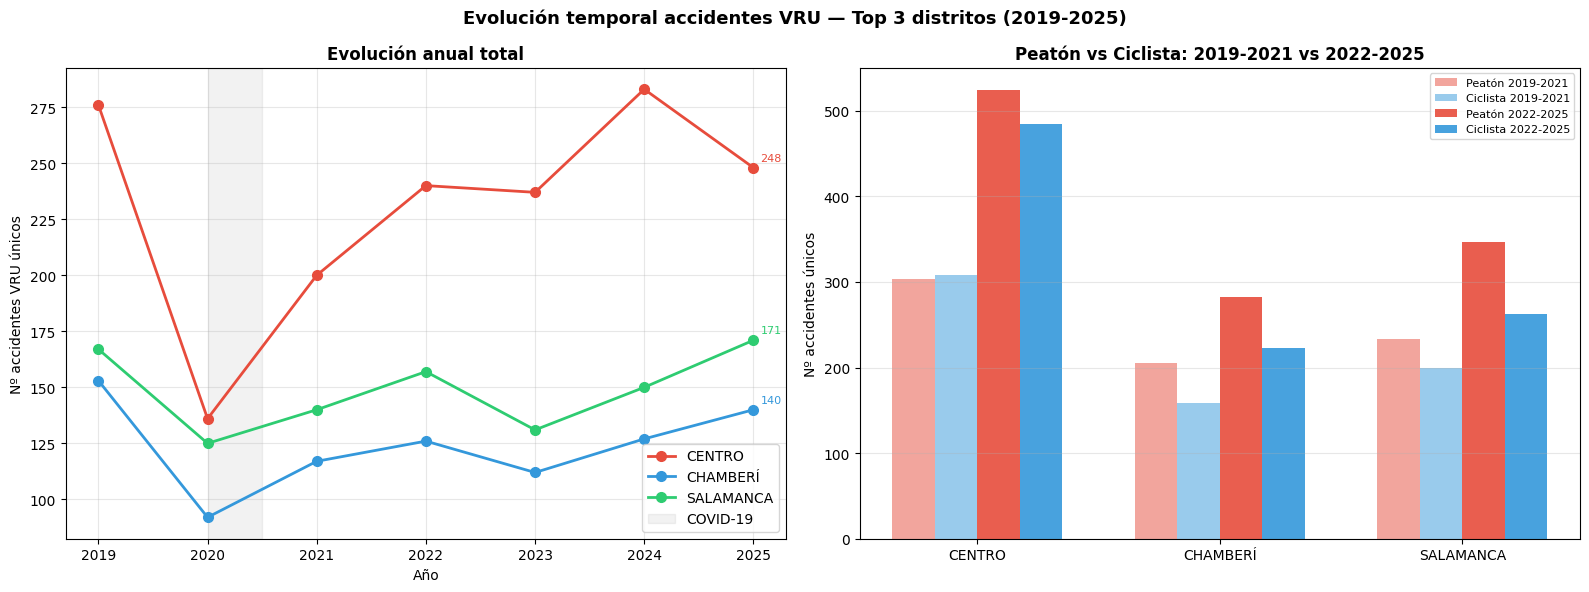

✅ top3_tendencia_tipo.png guardada


In [6]:
# ══════════════════════════════════════════════════════════
# CELDA 5 — Tendencia 2019-2025 y evolución por tipo VRU
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Evolución temporal accidentes VRU — Top 3 distritos (2019-2025)',
             fontsize=13, fontweight='bold')

# Izquierda: evolución anual total
ax = axes[0]
for distrito in TOP3:
    d = df_top3[df_top3['distrito'] == distrito]
    anual = d.groupby('año')['num_expediente'].nunique()
    ax.plot(anual.index, anual.values, marker='o', linewidth=2,
            label=distrito, color=colores[distrito], markersize=7)
    # Anotamos 2025
    ax.annotate(f'{anual.iloc[-1]}',
                xy=(anual.index[-1], anual.iloc[-1]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, color=colores[distrito])

ax.axvspan(2020, 2020.5, alpha=0.1, color='gray', label='COVID-19')
ax.set_xlabel('Año')
ax.set_ylabel('Nº accidentes VRU únicos')
ax.set_title('Evolución anual total', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(range(2019, 2026))

# Derecha: peatón vs ciclista por distrito
ax2 = axes[1]
x = np.arange(len(TOP3))
width = 0.35

for i, año_grupo in enumerate(['2019-2021', '2022-2025']):
    años = [2019,2020,2021] if i == 0 else [2022,2023,2024,2025]
    d_periodo = df_top3[df_top3['año'].isin(años)]
    peat = [d_periodo[(d_periodo['distrito']==dis) &
                      (d_periodo['tipo_vru']=='Peatón')]['num_expediente'].nunique()
            for dis in TOP3]
    bici = [d_periodo[(d_periodo['distrito']==dis) &
                      (d_periodo['tipo_vru']=='Ciclista')]['num_expediente'].nunique()
            for dis in TOP3]
    offset = width * (i - 0.5)
    bars_p = ax2.bar(x + offset - width/4, peat, width/2,
                     label=f'Peatón {año_grupo}',
                     color=['#E74C3C','#3498DB','#2ECC71'][0],
                     alpha=0.9 if i==1 else 0.5)
    bars_b = ax2.bar(x + offset + width/4, bici, width/2,
                     label=f'Ciclista {año_grupo}',
                     color=['#E74C3C','#3498DB','#2ECC71'][1],
                     alpha=0.9 if i==1 else 0.5)

ax2.set_xticks(x)
ax2.set_xticklabels(TOP3)
ax2.set_ylabel('Nº accidentes únicos')
ax2.set_title('Peatón vs Ciclista: 2019-2021 vs 2022-2025', fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{outputs}/top3_tendencia_tipo.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ top3_tendencia_tipo.png guardada')

In [7]:
# ══════════════════════════════════════════════════════════
# CELDA 6 — Recomendaciones de intervención por distrito
# ══════════════════════════════════════════════════════════

print('╔══════════════════════════════════════════════════════════════╗')
print('║        RECOMENDACIONES DE INTERVENCIÓN — TOP 3               ║')
print('╚══════════════════════════════════════════════════════════════╝')

for distrito in TOP3:
    d = df_top3[df_top3['distrito'] == distrito].copy()

    # Métricas clave
    total_acc   = d['num_expediente'].nunique()
    pct_peaton  = (d[d['tipo_vru']=='Peatón']['num_expediente'].nunique() / total_acc * 100)
    pct_ciclista= (d[d['tipo_vru']=='Ciclista']['num_expediente'].nunique() / total_acc * 100)

    hora_pico   = d.groupby('hora_int')['num_expediente'].nunique().idxmax()
    dia_pico    = d.groupby('dia_sem')['num_expediente'].nunique().idxmax()

    tipo_ppal   = d.groupby('num_expediente')['tipo_accidente'].first() \
                   .value_counts().index[0]

    edad_ppal   = d['rango_edad'].value_counts().index[0]

    d['calle_norm'] = d['localizacion'].str.strip().str.upper() \
                                        .str.replace(r'\d+$','',regex=True).str.strip()
    calle_ppal  = d.groupby('calle_norm')['num_expediente'].nunique().idxmax()

    exp_dedup = d.groupby('num_expediente').agg(
        gravedad_max=('gravedad', lambda x:
            x.map({'fallecido':4,'grave':3,'leve':2,
                   'sin_asistencia':1,'desconocido':0}).max())
    ).reset_index()
    pct_graves = (exp_dedup['gravedad_max'] >= 3).sum() / len(exp_dedup) * 100

    print(f'\n{"═"*62}')
    print(f'  {distrito}')
    print(f'{"═"*62}')
    print(f'  Accidentes VRU únicos 2019-2025: {total_acc}')
    print(f'  Peatones: {pct_peaton:.1f}% | Ciclistas: {pct_ciclista:.1f}%')
    print(f'  Graves+Fallecidos: {pct_graves:.1f}%')
    print(f'  Hora pico: {hora_pico}h | Día pico: {dia_pico}')
    print(f'  Tipo accidente principal: {tipo_ppal}')
    print(f'  Rango edad más frecuente: {edad_ppal}')
    print(f'  Calle más peligrosa: {calle_ppal[:50]}')
    print(f'\n  RECOMENDACIONES:')

    # Recomendaciones automáticas basadas en los datos
    if hora_pico in range(7, 10) or hora_pico in range(14, 16):
        print(f'  → Reforzar vigilancia en hora punta ({hora_pico}h)')
        print(f'    Instalar semáforos con fase peatonal exclusiva en cruces principales')
    if hora_pico in range(20, 24) or hora_pico in range(0, 6):
        print(f'  → Mejorar iluminación nocturna ({hora_pico}h)')
        print(f'    Señalización reflectante en pasos de peatones')
    if pct_ciclista > 30:
        print(f'  → Alto % ciclistas ({pct_ciclista:.1f}%):')
        print(f'    Ampliar red de carril bici segregado')
        print(f'    Instalar separadores físicos en carriles compartidos')
    if pct_peaton > 60:
        print(f'  → Predominio peatonal ({pct_peaton:.1f}%):')
        print(f'    Ampliar aceras en {calle_ppal[:40]}')
        print(f'    Reducir velocidad máxima a 20km/h en zonas de alta peatonalización')
    if pct_graves > 15:
        print(f'  → Alta gravedad ({pct_graves:.1f}% graves/fallecidos):')
        print(f'    Implantar zona 30 en vías con mayor siniestralidad grave')
        print(f'    Revisar diseño de intersecciones en {calle_ppal[:40]}')
    if 'atropello' in tipo_ppal.lower():
        print(f'  → Tipo principal atropello:')
        print(f'    Elevar pasos de peatones (plataforma única)')
        print(f'    Instalar refugios peatonales en calles anchas')

print(f'\n✅ Análisis Top 3 completado')
print(f'Gráficos guardados: top3_horario_diasemana.png, '
      f'top3_tipo_perfil_gravedad.png, top3_calles_peligrosas.png, '
      f'top3_tendencia_tipo.png')

╔══════════════════════════════════════════════════════════════╗
║        RECOMENDACIONES DE INTERVENCIÓN — TOP 3               ║
╚══════════════════════════════════════════════════════════════╝

══════════════════════════════════════════════════════════════
  CENTRO
══════════════════════════════════════════════════════════════
  Accidentes VRU únicos 2019-2025: 1620
  Peatones: 51.1% | Ciclistas: 49.0%
  Graves+Fallecidos: 5.7%
  Hora pico: 21h | Día pico: Saturday
  Tipo accidente principal: Atropello a persona
  Rango edad más frecuente: De 25 a 29 años
  Calle más peligrosa: CALL. GRAN VIA,

  RECOMENDACIONES:
  → Mejorar iluminación nocturna (21h)
    Señalización reflectante en pasos de peatones
  → Alto % ciclistas (49.0%):
    Ampliar red de carril bici segregado
    Instalar separadores físicos en carriles compartidos
  → Tipo principal atropello:
    Elevar pasos de peatones (plataforma única)
    Instalar refugios peatonales en calles anchas

═══════════════════════════════